# 102.1. Get started with TAP

<div style="max-width:300px; float: left; margin-right: 1em">

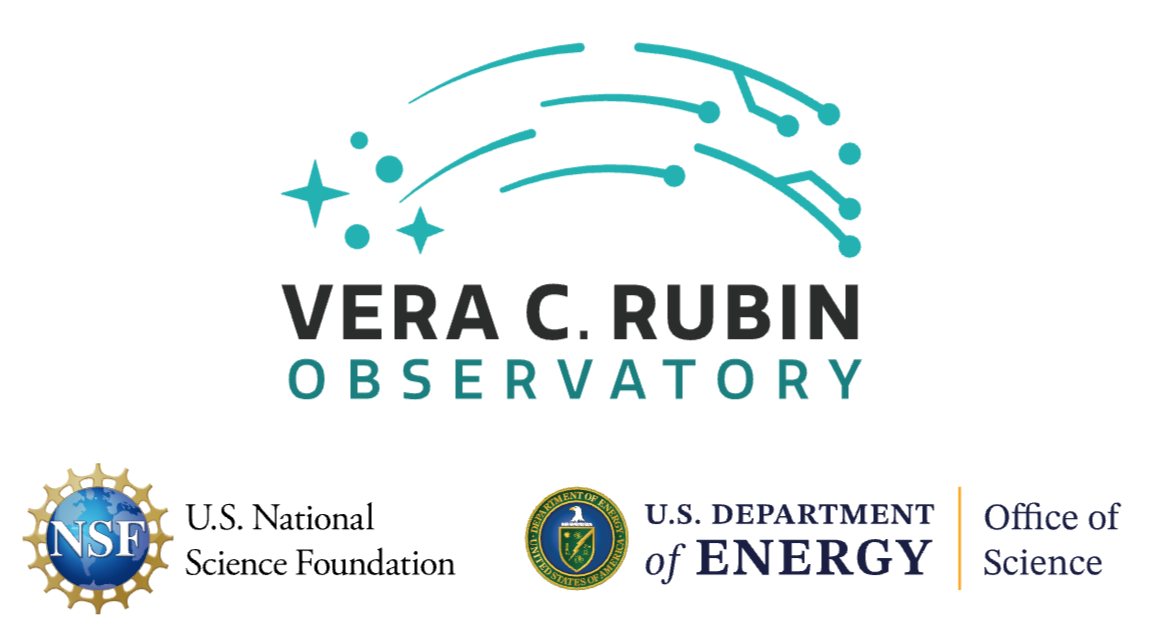

</div>

For the Rubin Science Platform at data.lsst.cloud. <br>
Data Release: <a href="https://dp1.lsst.io">Data Preview 1</a> <br>
Container Size: large <br>
LSST Science Pipelines version: r29.2.0 <br>
Last verified to run: 2026-04-17 <br>
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a> <br>
DOI: <a href="https://doi.org/10.11578/rubin/dc.20250909.20">10.11578/rubin/dc.20250909.20</a> <br>

**Learning objective:** How to use the TAP service efficiently.

**LSST data products:** `Object` table

**Packages:** `lsst.rsp.get_tap_service`

**Credit:** Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

TAP (Table Access Protocol) provides standardized access to catalog data for discovery, search, and retrieval.
Full [documentation for TAP](http://www.ivoa.net/documents/TAP) is provided by the
International Virtual Observatory Alliance (IVOA).

This tutorial demonstrates how to get started with the TAP service, explore the TAP schema, and make efficient queries.

Best practices for TAP queries:

1. Use asynchronous queries.
2. Specify the columns to be returned.
3. Use spatial constraints on sky coordinates.
4. Apply column constraints (as appropriate).

**Related tutorials**: The other 100-level tutorials in this series demonstrate advanced ADQL statements. The 200-level tutorials describe the contents of the catalog data and have example queries for each.


### 1.1. TAP glossary

* **schema** - Database terminology for the abstract design that represents the storage of data in a database.
* **TAP schema** - The set of tables that describe the data tables and their columns.
* **table collection** - A collection of tables (catalogs), e.g., for a given data release.
* **table** - A collection of related data held in a table format in a database. 
* **query** - A string formatted in ADQL that selects data from a table, with contraints if desired. 
* **results** - The output of the TAP service's search method when a query is passed.


### 1.2. ADQL statements

The [documentation for ADQL](http://www.ivoa.net/documents/latest/ADQL.html)
includes more information about syntax, keywords, operators, functions, and so on.
ADQL is similar to SQL (Structured Query Langage).

A typical ADQL statement has at least three components:

```
SELECT <columns> FROM <catalog> WHERE <constraints>
```

where
 * `<columns>` is a comma-separated list of the columns to return,
 * `<catalog>` is the name of the catalog to retreive data from, and
 * `<constraints>` imposes a restriction that only rows with column values that meet the constraints are returned.

For example, say there is a catalog called "mysurveydata" with 5 columns, "col1", "col2", and so on.
The ADQL statement:

```
SELECT col3, col4, col5 FROM mysurveydata WHERE col1 > 0.5 AND col5 < 10
```

would 
return a table that has three columns, and as many rows as meet both of the restrictions in the `WHERE` statement.

### 1.3. Import packages

Import general python packages
[numpy](https://numpy.org/doc/stable/index.html)
and the RSP TAP service.

In [ ]:
import numpy as np
from lsst.rsp import get_tap_service

## 2. Instantiate the TAP service

Get an instance of the TAP service, and assert that it exists.

In [ ]:
service = get_tap_service("tap")
assert service is not None

## 3. Explore the TAP schema

Browsable TAP schema are accessible at [sdm-schemas.lsst.io](https://sdm-schemas.lsst.io/) and in the Portal Aspect's user interface.

This section demonstrates how to interact programmatically with the TAP schema.

### 3.1. Use caution with synchronous queries

A "synchronous" query is when the search is executed and the results are retrieved at the same time, and no other cells can be run while the search is executing.

Synchronous queries are best used sparingly, and only for retrieving table metadata, as in this section.

**Asynchronous** queries should be used when table data is being returned (Section 4.1).

### 3.2. Use caution with SELECT *

Queries that use `SELECT *`, which will retrieve all columns, are only appropriate for schemas (this section) or tables with very few (<20) columns.

Queries that return data should specify which of the tens to *hundreds* of columns are necessary to return (Section 4.2).

### 3.3. List all schemas

Pass a query for the TAP schemas to the TAP service, and store the results in `results`.

In [ ]:
results = service.search('SELECT * FROM tap_schema.schemas')

Show the results.

In [ ]:
results

The `to_table()` method converts `results` into an [Astropy table](https://docs.astropy.org/en/stable/table/).

Convert `results` to a `table` and display the table.

In [ ]:
results.to_table()

In [ ]:
del results

### 3.4. List all tables

Create a query that selects all table names from the TAP schema for DP1. Retrieve the results as an Astropy table and display it.

In [ ]:
query = "SELECT * FROM tap_schema.tables " \
        "WHERE tap_schema.tables.schema_name = 'dp1'" \
        "ORDER BY table_index ASC"
results = service.search(query).to_table()
results

In [ ]:
del query, results

### 3.5. List all columns

Create a query that selects all column names, data types, description, and units from the DP1 `Object` table. Retrieve the results as an Astropy table.

In [ ]:
query = "SELECT column_name, datatype, description, unit " \
        "FROM tap_schema.columns " \
        "WHERE table_name = 'dp1.Object'"
results = service.search(query).to_table()

Option to display the `results`. The table's display will automatically be truncated by the notebook because the `Object` table has 1296 columns.

In [ ]:
# results

Use a `for` loop to look for the presence of `coord` in the
`column_name` column for every row of the results table,
and write the name when there is a match.

In [ ]:
search_string = 'coord'
for cname in results['column_name']:
    if cname.find(search_string) > -1:
        print(cname)

Uncomment the second line in the cell above and re-execute it to print all columns containing the string `g_psfFlux`.

Print the unique set of data types or units.

In [ ]:
print(np.unique(results['datatype']))
# print(np.unique(results['unit']))

In [ ]:
del query, results

## 4. Best practices for TAP queries

It is recommended to follow the guidance in this section when querying for and retrieving data because the TAP service is a limited resource that is shared by all users.

This tutorial will demonstrate how to make efficient queries that return only the data needed for a given analysis.

The `Object` table used in this demonstration contains forced measurements in the multi-band `deep_coadd` images at the coordinates of all signal-to-noise ratio >5 detections in a `deep_coadd` of any filter.
The 200-level tutorial for the `Object` catalog contains further detail.

### 4.1. Use asynchronous queries

An "asynchronous" query means that the query is submitted as a job to the TAP service, and it runs in the background until it completes. The results can then be retrieved right away, or at a later time.

The general process for asynchronous queries is as follows.

1. Define the `job` by passing the `query` to the TAP service.

```
job = service.submit_job(query)
```

2. Run the job and wait for it to return either a COMPLETED or ERROR result. While waiting is optional, tutorial notebooks always wait because the next steps of a tutorial depend on having the retrieved data.

```
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
```

3. Display the error message if the query was not successful.

```
if job.phase == 'ERROR':
    job.raise_if_error()
```

4. If the query was completed, retrieve (fetch) the results.

```
assert job.phase == 'COMPLETED'
results = job.fetch_result()
```

### 4.2. Use the Job Monitor

To monitor the status of your jobs, open a new 'Launcher' tab by clicking the '+' icon at the top. 
<div style="max-width:400px; float: left; margin-right: 1em">
    
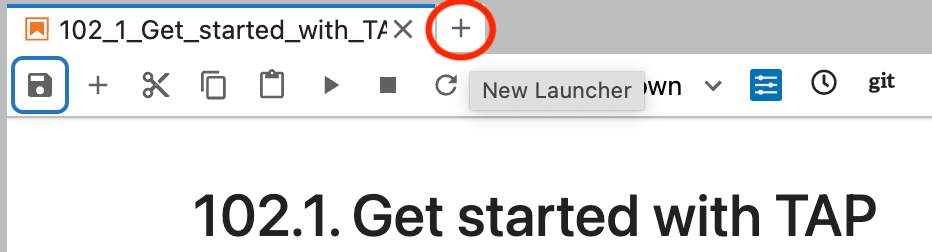

</div> 
<div style="clear: both;"></div>

From the Launcher menu, select 'Firefly Viewer.' 
<div style="max-width:500px; float: left; margin-right: 1em">
    
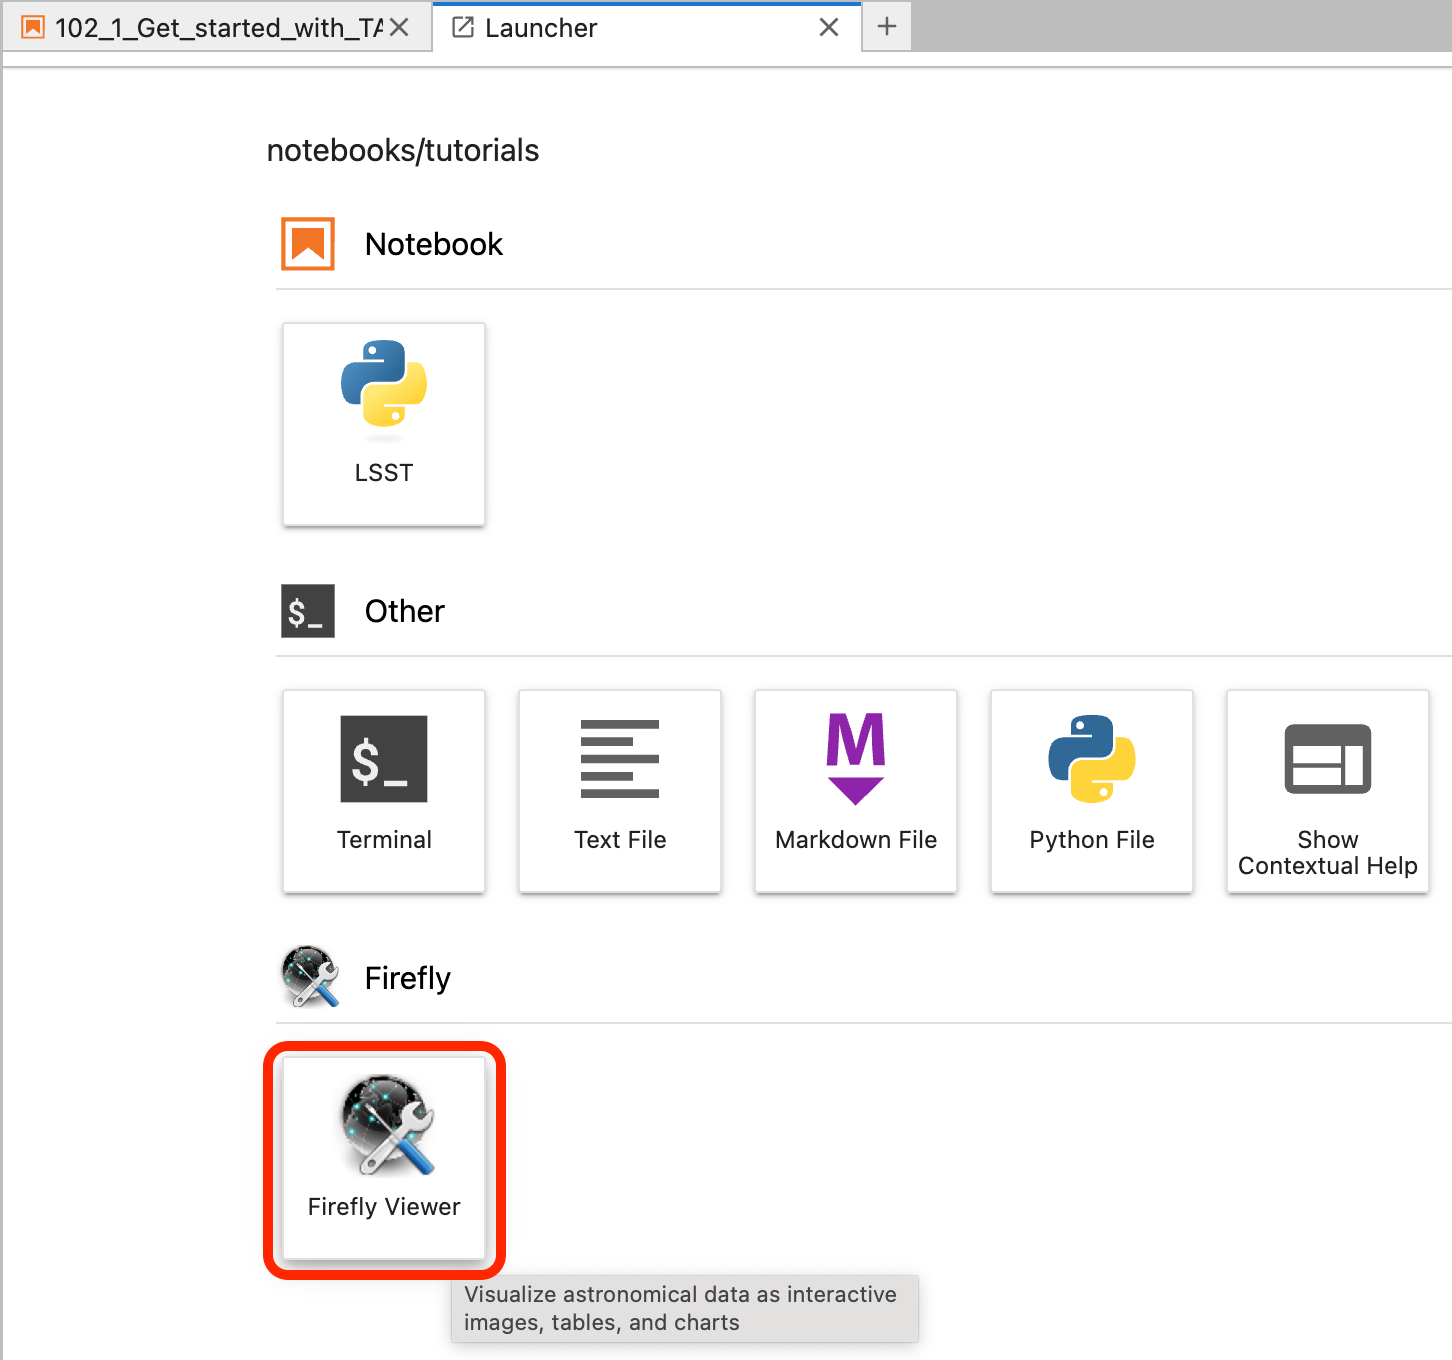

</div>
<div style="clear: both;"></div>

Once the Firefly Viewer tab is open, click the 'Job Monitor' tab at the top. This will display your most recent jobs, including the job title, service ID, type, start time, end time, and phase. The 'Control' column provides options to view job results, inspect job information (including the associated ADQL query), and delete the job.
<div style="max-width:800px; float: left; margin-right: 1em">
    
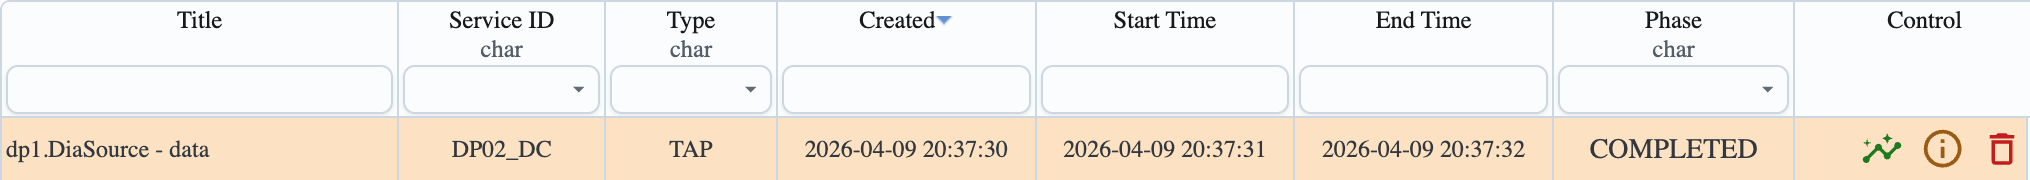
</div>

### 4.3. Use SELECT to specify columns

Queries for data should **not use** `SELECT *`, as this will retrieve all columns, and some tables have *hundreds* of columns.

It is recommended to first decide which columns are necessary to retrieve.
Use the [TAP schema](https://sdm-schemas.lsst.io/) to understand the available columns.
Then, specify only the desired columns in the TAP query's `SELECT` statement.

### 4.4. Use spatial constraints

All TAP searches on tables that include sky coordinates should include spatial constraints.

It is recommended to always start with spatial constraints for a small region and then expand the search area.

Spatial constraints should be implemented with either an ADQL cone or polygon search.

For small, "quicklook" queries it is recommended to use a small spatial region rather than just limiting the results returned with `TOP`.

#### 4.4.1. Table sharding by coordinate

On disk, the catalog tables are sharded by coordinate (RA, Dec). This can be thought of as the database being divided up by spatial region (shard) and distributed across multiple servers. Queries that include spatial constraints which minimize the number of shards that have to be searched through will be much faster than queries that have no (or very wide) spatial constraints.

#### 4.4.2. Cone searches 

A cone search means a catalog query that returns all objects within a given radius of a sky coordinate.
Since a given angular diameter corresponds to a larger physical diameter at larger distances,
the volume queried is a cone shape in 3D, not a cylinder.

In ADQL, a cone search is executed with `WHERE CONTAINS(POINT(), CIRCLE()) = 1`.
 * `POINT()` passes the catalog's columns for sky coordinates.
 * `CIRCLE()` defines the center and radius of the search circle.
 * `CONTAINS() = 1` constrains the query to only return rows for which the statement "this circle contains this point" is "True" (=1).

Column constraints on the coordinates, either with ADQL like `-30 < coord_dec AND coord_dec < -25` or using a `WHERE ... BETWEEN` statement, are not recommended because the TAP service doesn't interpret them the same as a cone or polygon search.

Create a cone search on the `Object` table for objects within 0.01 degrees of coordinates near the center of the ECDFS field, RA, Dec = 53, -28 degrees.

In [ ]:
query = """SELECT coord_ra, coord_dec
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
        CIRCLE('ICRS', 53, -28, 0.01)) = 1"""
print(query)

Execute the query asynchronously, and print the number of rows returned.

In [ ]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

In [ ]:
assert job.phase == 'COMPLETED'
results = job.fetch_result()
print(len(results))

Clean up.

In [ ]:
job.delete()
del query, results

#### 4.4.3. Polygon searches

For a polygon search, replace `CIRCLE` with `POLYGON(ra1, dec1, ra2, dec2, ra3, dec3, ...)` where each `ra1, dec` is a vertex of the polygon.

### 4.5. Use column constraints

It is recommended to understand the columns being retrieved (Section 4.2) and, if appropriate, to also place constraints on those columns' values. The point is to only return table rows that are relevant to the analysis (e.g., only objects of interest).

For example, a simple column constraint is to put an upper or lower limit on the values in a column, such as a limiting magnitude.

Use the same cone search as above, but extend the radius to $0.3$ degrees and only return `Objects` with a $g$-band `cModel` magnitude brighter than 20 mag.

In [ ]:
query = """SELECT coord_ra, coord_dec, g_cModelMag
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
        CIRCLE('ICRS', 53, -28, 0.3)) = 1
        AND g_cModelMag < 20"""
print(query)

In [ ]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

In [ ]:
assert job.phase == 'COMPLETED'
results = job.fetch_result()
print(len(results))

Clean up.

In [ ]:
job.delete()
del query, results